In [158]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [159]:
plt.style.use("ggplot")

In [160]:
df = pd.read_csv('email.csv')

In [161]:
df.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [162]:
df['Category'].value_counts()

Category
ham               4825
spam               747
{"mode":"full"       1
Name: count, dtype: int64

In [163]:
df

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...
5571,ham,Rofl. Its true to its name


In [164]:
df.shape

(5573, 2)

In [165]:
df.dtypes

Category    object
Message     object
dtype: object

In [166]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5573 entries, 0 to 5572
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  5573 non-null   object
 1   Message   5573 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [167]:
df.isnull().sum()

Category    0
Message     0
dtype: int64

In [168]:
df.duplicated().sum()/df.shape[0]

np.float64(0.07446617620671092)

In [169]:
df.drop_duplicates(inplace=True)

In [170]:
df

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...
5571,ham,Rofl. Its true to its name


In [171]:
df['Category'].value_counts()

Category
ham               4516
spam               641
{"mode":"full"       1
Name: count, dtype: int64

In [172]:
df['Category'].value_counts(normalize=True)*100

Category
ham               87.553315
spam              12.427297
{"mode":"full"     0.019387
Name: proportion, dtype: float64

In [173]:
df[df['Category'].str.contains('mode', na=False)]

,Category,Message
5572,"{""mode"":""full""",isActive:false}


In [174]:
df = df[df['Category'].isin(['ham', 'spam'])]

Text(0.5, 1.0, 'Email Category Distribution')

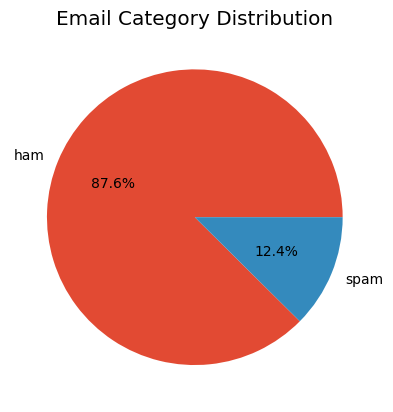

In [175]:
df['Category'].value_counts().plot(kind='pie',autopct="%1.1f%%")
plt.ylabel("")
plt.title("Email Category Distribution")

In [176]:
df = df.copy()
df.loc[:,"Message_Length"] = df["Message"].apply(len)

In [177]:
df

,Category,Message,Message_Length
0,ham,"Go until jurong point, crazy.. Available only ...",111
1,ham,Ok lar... Joking wif u oni...,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,ham,U dun say so early hor... U c already then say...,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",61
...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,160
5568,ham,Will ü b going to esplanade fr home?,36
5569,ham,"Pity, * was in mood for that. So...any other s...",57
5570,ham,The guy did some bitching but I acted like i'd...,125


In [178]:
df["Message_Length"].describe()

count    5157.000000
mean       79.103936
std        58.382922
min         2.000000
25%        36.000000
50%        61.000000
75%       118.000000
max       910.000000
Name: Message_Length, dtype: float64

In [179]:
df["Message"][1]

'Ok lar... Joking wif u oni...'

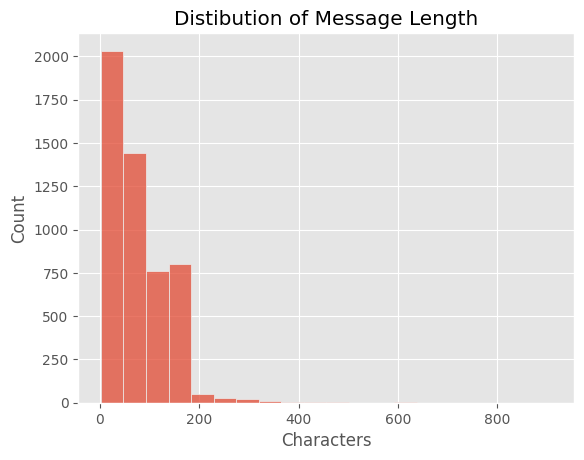

In [180]:
sns.histplot(df["Message_Length"],bins=20)
plt.title("Distibution of Message Length")
plt.xlabel("Characters")
plt.show()

In [181]:
df["Message_Length"].median()

61.0

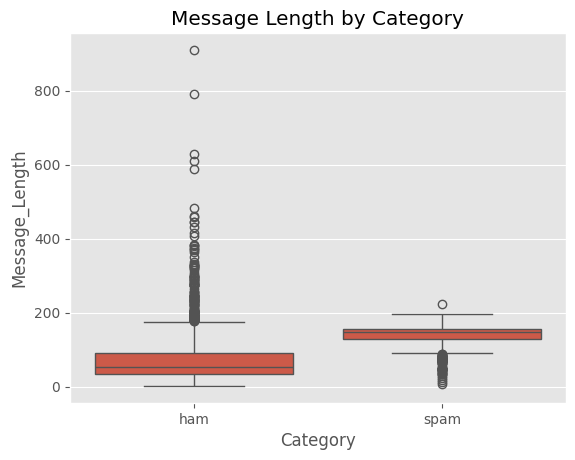

In [182]:
sns.boxplot(
    data=df,
    x= "Category",
    y= "Message_Length"
)
plt.title("Message Length by Category")
plt.show()

In [183]:
df.groupby("Category")["Message_Length"].mean()

Category
ham      70.869353
spam    137.118565
Name: Message_Length, dtype: float64

Text(0.5, 1.0, 'Average Message Length')

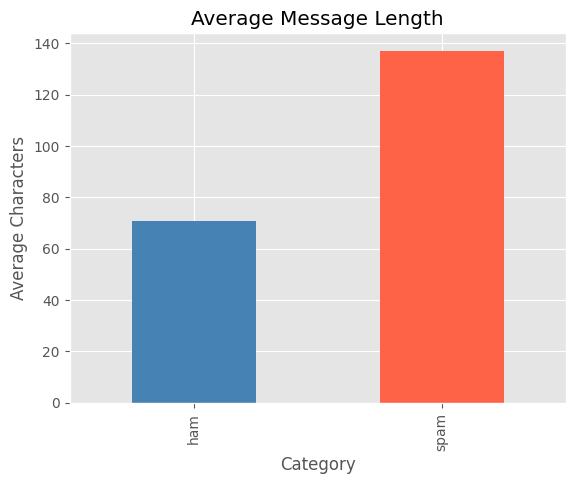

In [184]:
df.groupby("Category")["Message_Length"].mean().plot(kind="bar",
                                                    color=["Steelblue","tomato"]
                                                    )
plt.ylabel("Average Characters")
plt.title("Average Message Length")

In [185]:
df.head()

,Category,Message,Message_Length
0,ham,"Go until jurong point, crazy.. Available only ...",111
1,ham,Ok lar... Joking wif u oni...,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,ham,U dun say so early hor... U c already then say...,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",61


In [186]:
df = df.copy()
df.loc[:,"Word_Count"] = df["Message"].apply(lambda x :len(x.split()))

In [187]:
df

,Category,Message,Message_Length,Word_Count
0,ham,"Go until jurong point, crazy.. Available only ...",111,20
1,ham,Ok lar... Joking wif u oni...,29,6
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,28
3,ham,U dun say so early hor... U c already then say...,49,11
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,13
...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,160,30
5568,ham,Will ü b going to esplanade fr home?,36,8
5569,ham,"Pity, * was in mood for that. So...any other s...",57,10
5570,ham,The guy did some bitching but I acted like i'd...,125,26


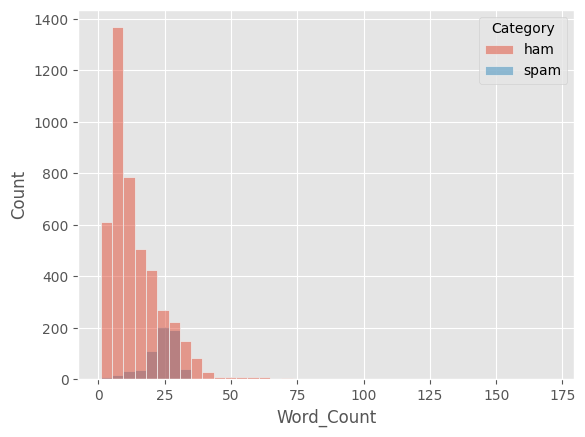

In [188]:
sns.histplot(
    data = df,
    x = "Word_Count",
    hue= "Category",
    bins=40
)
plt.show()

In [189]:
df.groupby("Category")["Word_Count"].mean()

Category
ham     14.239814
spam    23.659906
Name: Word_Count, dtype: float64

In [190]:
df.nsmallest(10,"Message_Length")

,Category,Message,Message_Length,Word_Count
1925,ham,Ok,2,1
3376,ham,:),2,1
261,ham,Yup,3,1
1612,ham,645,3,1
2182,ham,Ok.,3,1
287,ham,Ok..,4,1
2602,ham,Okie,4,1
5173,ham,U 2.,4,2
1273,ham,Ok...,5,1
4293,ham,G.W.R,5,1


In [191]:
df.nlargest(10,"Message_Length")

,Category,Message,Message_Length,Word_Count
1085,ham,For me the love should start with attraction.i...,910,171
1863,ham,The last thing i ever wanted to do was hurt yo...,790,162
2434,ham,Indians r poor but India is not a poor country...,629,109
1579,ham,How to Make a girl Happy? It's not at all diff...,611,103
2158,ham,Sad story of a Man - Last week was my b'day. M...,588,125
2380,ham,"Good evening Sir, hope you are having a nice d...",482,98
3017,ham,"&lt;#&gt; is fast approaching. So, Wish u a v...",461,66
1513,ham,"Hey sweet, I was wondering when you had a mome...",458,95
2370,ham,A Boy loved a gal. He propsd bt she didnt mind...,446,96
2408,ham,Solve d Case : A Man Was Found Murdered On &l...,444,71


In [192]:
df[df["Category"]=="spam"].sample(5)

,Category,Message,Message_Length,Word_Count
1252,spam,Please CALL 08712402779 immediately as there i...,81,13
424,spam,URGENT! Your Mobile number has been awarded wi...,136,22
5482,spam,URGENT We are trying to contact you Last weeke...,148,27
2680,spam,"New Tones This week include: 1)McFly-All Ab..,...",136,20
2209,spam,URGENT!! Your 4* Costa Del Sol Holiday or £500...,159,23


In [193]:
df[df["Category"]=="ham"].sample(5)

,Category,Message,Message_Length,Word_Count
2655,ham,Its sarcasm.. .nt scarcasim,27,4
1788,ham,Yes:)sura in sun tv.:)lol.,26,4
2040,ham,Dont pack what you can buy at any store.like c...,123,24
2641,ham,Pandy joined 4w technologies today.he got job..,47,7
4856,ham,Same to u...,12,3


In [194]:
df

,Category,Message,Message_Length,Word_Count
0,ham,"Go until jurong point, crazy.. Available only ...",111,20
1,ham,Ok lar... Joking wif u oni...,29,6
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,28
3,ham,U dun say so early hor... U c already then say...,49,11
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,13
...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,160,30
5568,ham,Will ü b going to esplanade fr home?,36,8
5569,ham,"Pity, * was in mood for that. So...any other s...",57,10
5570,ham,The guy did some bitching but I acted like i'd...,125,26


In [195]:
df["Category"] = df["Category"].map({
    "ham" : 0,
    "spam" : 1
})

In [196]:
from sklearn.model_selection import train_test_split


In [197]:
X = df["Message"]
y = df["Category"]

In [198]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,stratify=y)

In [199]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [200]:
tfidf = TfidfVectorizer(
    stop_words ="english",
    max_features = 5000,
    ngram_range = (1,2)
)

In [201]:
X_train_tfidf = tfidf.fit_transform(X_train)

In [202]:
X_test_tfidf = tfidf.transform(X_test)

In [203]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier


In [204]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score

In [208]:
from sklearn.model_selection import RandomizedSearchCV,ParameterGrid


In [206]:
models = {
    "Naive Bayes" : (
        MultinomialNB(),
        {
            "alpha" : [0.1,0.5,1,2,5]
        }
    ),
    "LogisticRegression" : (
        LogisticRegression(
            class_weight="balanced",
            max_iter=1000
        ),
        {
            "C" : [0.01,0.1,1,10,100]
        }
    ),
    "Linear SVM" : (
        LinearSVC(
            class_weight = "balanced"
        ),
        {
            "C" : [0.01,0.1,1,10]
        }
    ),
    "RandomForest" : (
        RandomForestClassifier(
            class_weight= "balanced"
        ),
        {
            "n_estimators":[100,200,300],
            "max_depth" : [10,20,None],
            "min_samples_split" : [2,5,10]
        }
    ),
    "Decision Tree" : (
        DecisionTreeClassifier(
            class_weight="balanced"
        ),
        {
            "max_depth" : [5,10,20,None],
            "min_samples_split" : [2,5,10]
        }
    ),
    "Gradient Boosting" :(
        GradientBoostingClassifier(),
        {
            "n_estimators" : [100,200],
            "learning_rate" : [0.01,0.05,0.1],
            "max_depth" : [3,5]
        }
    ),
    "KNN" : (
        KNeighborsClassifier(),
        {
           "n_neighbors": [3,5,7,9]
        }
    )
}

In [209]:
results = []

best_models = {}

for name,(model,params) in models.items():
    total_combinations = len(list(ParameterGrid(params)))
    n_iter = min(10, total_combinations)
    search = RandomizedSearchCV(
        estimator =model,
        param_distributions=params,
        n_iter = n_iter,
        cv=5,
        scoring="f1",
        n_jobs=-1
    )
    search.fit(X_train_tfidf,y_train)

    best_model = search.best_estimator_

    best_models[name] = best_model

    predictions = best_model.predict(X_test_tfidf)

    accuracy = accuracy_score(y_test,predictions)
    precision = precision_score(y_test,predictions)
    recall = recall_score(y_test,predictions)
    f1 = f1_score(y_test,predictions)

    try :
        auc = roc_auc_score(y_test,best_model.decision_function(X_test_tfidf))
    except :
        try :
            auc = roc_auc_score(
                y_test,
                best_model.predict_proba(X_test_tfidf)[:,1]
            )
        except :
            auc = np.nan
    results.append({
        "Model" : name,
        "Accuracy" : accuracy,
        "Precision": precision,
        "Recall" : recall,
        "F1 Score" : f1,
        "ROC AUC" : auc,
        "Best params" : search.best_params_
    })

In [210]:
results

[{'Model': 'Naive Bayes',
  'Accuracy': 0.9893410852713178,
  'Precision': 1.0,
  'Recall': 0.9140625,
  'F1 Score': 0.9551020408163265,
  'ROC AUC': 0.9906232715707964,
  'Best params': {'alpha': 0.1}},
 {'Model': 'LogisticRegression',
  'Accuracy': 0.9864341085271318,
  'Precision': 0.9672131147540983,
  'Recall': 0.921875,
  'F1 Score': 0.944,
  'ROC AUC': 0.9853083517699115,
  'Best params': {'C': 100}},
 {'Model': 'Linear SVM',
  'Accuracy': 0.9874031007751938,
  'Precision': 0.967479674796748,
  'Recall': 0.9296875,
  'F1 Score': 0.9482071713147411,
  'ROC AUC': 0.9872874032079646,
  'Best params': {'C': 1}},
 {'Model': 'RandomForest',
  'Accuracy': 0.9844961240310077,
  'Precision': 0.9666666666666667,
  'Recall': 0.90625,
  'F1 Score': 0.9354838709677419,
  'ROC AUC': 0.9903035121681416,
  'Best params': {'n_estimators': 200,
   'min_samples_split': 10,
   'max_depth': None}},
 {'Model': 'Decision Tree',
  'Accuracy': 0.9544573643410853,
  'Precision': 0.7872340425531915,
  'Re

In [211]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by=["F1 Score","ROC AUC"],
    ascending= False
)

In [212]:
results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,Best params
0,Naive Bayes,0.989341,1.000000,0.914062,0.955102,0.990623,{'alpha': 0.1}
2,Linear SVM,0.987403,0.967480,0.929688,0.948207,0.987287,{'C': 1}
1,LogisticRegression,0.986434,0.967213,0.921875,0.944000,0.985308,{'C': 100}
3,RandomForest,0.984496,0.966667,0.906250,0.935484,0.990304,"{'n_estimators': 200, 'min_samples_split': 10,..."
5,Gradient Boosting,0.970930,0.990000,0.773438,0.868421,0.982245,"{'n_estimators': 200, 'max_depth': 3, 'learnin..."
4,Decision Tree,0.954457,0.787234,0.867188,0.825279,0.919490,"{'min_samples_split': 5, 'max_depth': None}"
6,KNN,0.918605,1.000000,0.343750,0.511628,0.788700,{'n_neighbors': 3}


In [213]:
results_df.style.background_gradient(
    cmap = "Greens",
    subset = ["Accuracy","Precision","Recall","F1 Score","ROC AUC"]
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,Best params
0,Naive Bayes,0.989341,1.000000,0.914062,0.955102,0.990623,{'alpha': 0.1}
2,Linear SVM,0.987403,0.967480,0.929688,0.948207,0.987287,{'C': 1}
1,LogisticRegression,0.986434,0.967213,0.921875,0.944000,0.985308,{'C': 100}
3,RandomForest,0.984496,0.966667,0.906250,0.935484,0.990304,"{'n_estimators': 200, 'min_samples_split': 10, 'max_depth': None}"
5,Gradient Boosting,0.970930,0.990000,0.773438,0.868421,0.982245,"{'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.1}"
4,Decision Tree,0.954457,0.787234,0.867188,0.825279,0.919490,"{'min_samples_split': 5, 'max_depth': None}"
6,KNN,0.918605,1.000000,0.343750,0.511628,0.788700,{'n_neighbors': 3}


In [214]:
results_df.reset_index(inplace=True)

In [215]:
results_df

,index,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,Best params
0,0,Naive Bayes,0.989341,1.000000,0.914062,0.955102,0.990623,{'alpha': 0.1}
1,2,Linear SVM,0.987403,0.967480,0.929688,0.948207,0.987287,{'C': 1}
2,1,LogisticRegression,0.986434,0.967213,0.921875,0.944000,0.985308,{'C': 100}
3,3,RandomForest,0.984496,0.966667,0.906250,0.935484,0.990304,"{'n_estimators': 200, 'min_samples_split': 10,..."
4,5,Gradient Boosting,0.970930,0.990000,0.773438,0.868421,0.982245,"{'n_estimators': 200, 'max_depth': 3, 'learnin..."
5,4,Decision Tree,0.954457,0.787234,0.867188,0.825279,0.919490,"{'min_samples_split': 5, 'max_depth': None}"
6,6,KNN,0.918605,1.000000,0.343750,0.511628,0.788700,{'n_neighbors': 3}


In [216]:
results_df.drop(columns="index",inplace=True)

In [217]:
results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,Best params
0,Naive Bayes,0.989341,1.000000,0.914062,0.955102,0.990623,{'alpha': 0.1}
1,Linear SVM,0.987403,0.967480,0.929688,0.948207,0.987287,{'C': 1}
2,LogisticRegression,0.986434,0.967213,0.921875,0.944000,0.985308,{'C': 100}
3,RandomForest,0.984496,0.966667,0.906250,0.935484,0.990304,"{'n_estimators': 200, 'min_samples_split': 10,..."
4,Gradient Boosting,0.970930,0.990000,0.773438,0.868421,0.982245,"{'n_estimators': 200, 'max_depth': 3, 'learnin..."
5,Decision Tree,0.954457,0.787234,0.867188,0.825279,0.919490,"{'min_samples_split': 5, 'max_depth': None}"
6,KNN,0.918605,1.000000,0.343750,0.511628,0.788700,{'n_neighbors': 3}


In [77]:
best_model_name = results_df.iloc[0]["Model"]

In [78]:
best_model_name

'Naive Bayes'

In [79]:
best_model = best_models[best_model_name]

In [80]:
best_model

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",0.1
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


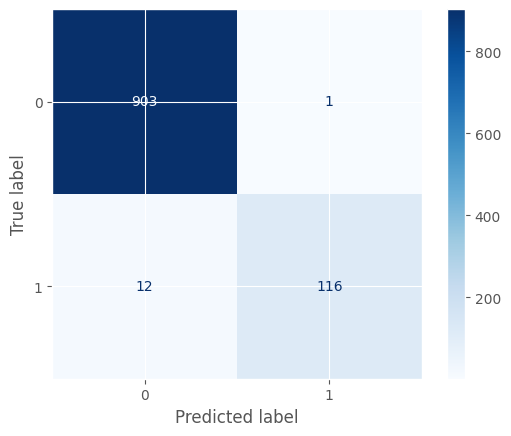

In [84]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    best_model,
    X_test_tfidf,
    y_test,
    cmap="Blues"
)
plt.show()

In [85]:
## example

In [86]:
emails = [
    "Congratulations! You won a free iPhone . Click Here Now.",
    "Hey ,are we still meeting tomorrow at 10 AM?",
    "URGENT ! Claim Your Walmart Gift Card Today"
]

In [88]:
emails_vectorized = tfidf.transform(emails)
predictions = best_model.predict(emails_vectorized)

for email, prediction in zip(emails,predictions):
    label = "Spam" if prediction==1 else "Ham"
    print(f"Email : {email}")
    print(f"Prediction : {label}")
    print("-"*70)

Email : Congratulations! You won a free iPhone . Click Here Now.
Prediction : Spam
----------------------------------------------------------------------
Email : Hey ,are we still meeting tomorrow at 10 AM?
Prediction : Ham
----------------------------------------------------------------------
Email : URGENT ! Claim Your Walmart Gift Card Today
Prediction : Spam
----------------------------------------------------------------------


In [90]:
import pickle

with open("spam_classifier.pkl","wb") as file :
    pickle.dump(best_model,file)

In [99]:
with open("tfidf_vectorizer.pkl","wb") as file :
    pickle.dump(tfidf,file)

In [100]:
with open("spam_classifier.pkl","rb") as file :
    loaded_model = pickle.load(file)
with open("tfidf_vectorizer.pkl","rb") as file :
    loaded_vectorizer = pickle.load(file)

In [103]:
email = [
    "Congratulations! You won a free iPhone . Click Here Now."]
email_vector = loaded_vectorizer.transform(email)
prediction = loaded_model.predict(email_vector)

In [104]:
print("Spam" if prediction==1 else "Ham")

Spam
